## **Dataset Preparation**

In [9]:
!pip install nvidia-dali-cuda120 huggingface_hub datasets torchvision cupy-cuda12x

import os
import cv2
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms.functional as F
from datasets import load_dataset
import nvidia.dali.fn as fn
import nvidia.dali.types as types
from nvidia.dali.pipeline import Pipeline

os.makedirs("test_images", exist_ok=True)
ds = load_dataset("beans", split="train", streaming=True)
image_paths = []

for i, item in enumerate(ds):
    if i >= 25:
        break
    path = f"test_images/img_{i}.jpg"
    item['image'].save(path, "JPEG")
    image_paths.append(path)

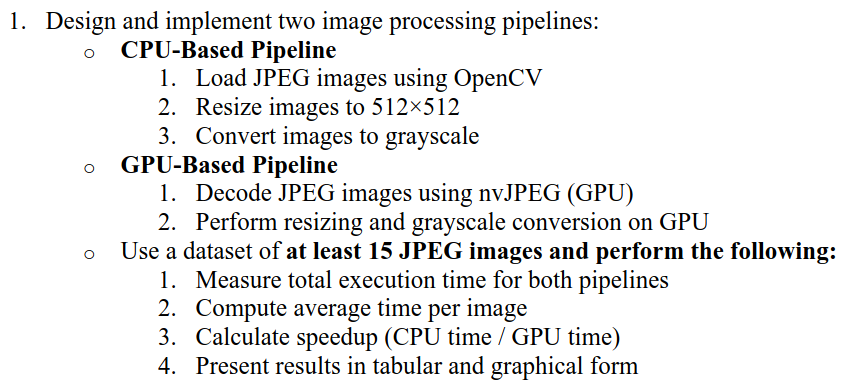

This cell implements both pipelines, measures the execution time, calculates the speedup, and presents the results in tabular and graphical formats.

Task 1 Results:
          Metric       CPU      GPU
  Total Time (s)  0.037802 0.025615
Average Time (s)   0.00252 0.001708
         Speedup         - 1.475781


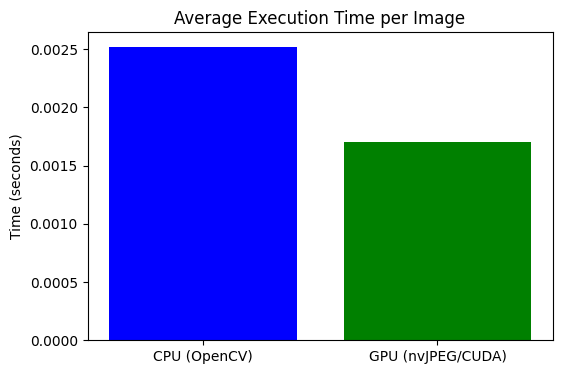

In [10]:
def cpu_pipeline(paths):
    start = time.time()
    for p in paths:
        img = cv2.imread(p)
        img = cv2.resize(img, (512, 512))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return time.time() - start

def gpu_pipeline(paths):
    start = time.time()
    for p in paths:
        raw_data = torch.from_file(p, shared=False, size=os.path.getsize(p), dtype=torch.uint8)
        img = torchvision.io.decode_jpeg(raw_data, device='cuda')
        img = F.resize(img, [512, 512], antialias=True)
        img = F.rgb_to_grayscale(img)
    torch.cuda.synchronize()
    return time.time() - start

subset = image_paths[:15]
cpu_total = cpu_pipeline(subset)
gpu_total = gpu_pipeline(subset)

cpu_avg = cpu_total / 15
gpu_avg = gpu_total / 15
speedup = cpu_total / gpu_total

df1 = pd.DataFrame({
    "Metric": ["Total Time (s)", "Average Time (s)", "Speedup"],
    "CPU": [cpu_total, cpu_avg, "-"],
    "GPU": [gpu_total, gpu_avg, speedup]
})
print("Task 1 Results:")
print(df1.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(["CPU (OpenCV)", "GPU (nvJPEG/CUDA)"], [cpu_avg, gpu_avg], color=['blue', 'green'])
plt.title("Average Execution Time per Image")
plt.ylabel("Time (seconds)")
plt.show()

**Why does GPU-based decoding using nvJPEG provide
significant speedup compared to CPU decoding, and under what conditions might this advantage reduce?**

GPUs accelerate image processing by using parallel computation for intensive tasks like Huffman decoding and the inverse discrete cosine transform (IDCT), handling multiple image blocks at once. However, this performance benefit is often lost when PCIe data transfer times outweigh actual processing—especially with very small images, sequential (non-batched) operations, or when high-end CPUs with AVX optimizations outperform lower-end GPUs.

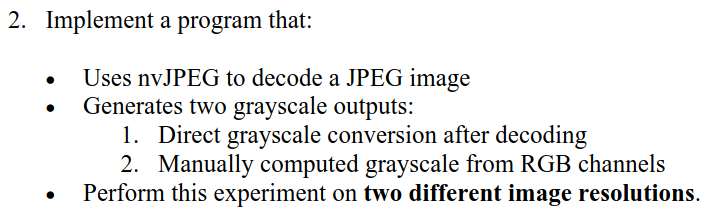

This block decodes a JPEG using the GPU, processes it at two different resolutions, and outputs the comparative grayscale matrices.

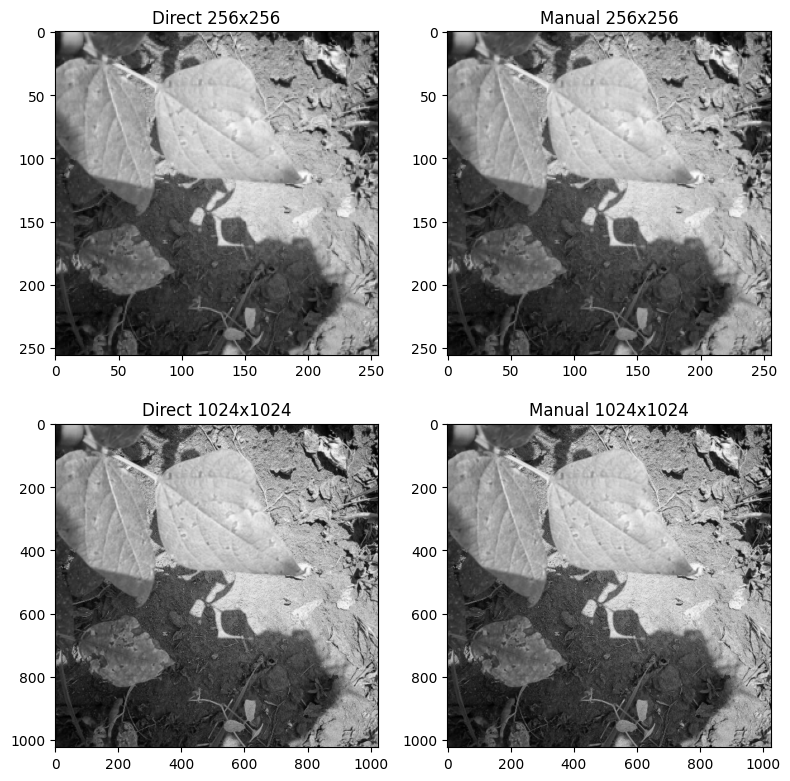

In [11]:
def task2_experiment(path, target_size):
    raw_data = torch.from_file(path, shared=False, size=os.path.getsize(path), dtype=torch.uint8)
    img = torchvision.io.decode_jpeg(raw_data, device='cuda')
    img = F.resize(img, target_size, antialias=True)

    gray_direct = F.rgb_to_grayscale(img)

    img_float = img.float()
    gray_manual = 0.299 * img_float[0] + 0.587 * img_float[1] + 0.114 * img_float[2]
    gray_manual = gray_manual.unsqueeze(0).to(torch.uint8)

    return gray_direct, gray_manual

img_path = image_paths[0]
res1_direct, res1_manual = task2_experiment(img_path, [256, 256])
res2_direct, res2_manual = task2_experiment(img_path, [1024, 1024])

fig, ax = plt.subplots(2, 2, figsize=(8, 8))
ax[0,0].imshow(res1_direct[0].cpu().numpy(), cmap='gray')
ax[0,0].set_title("Direct 256x256")
ax[0,1].imshow(res1_manual[0].cpu().numpy(), cmap='gray')
ax[0,1].set_title("Manual 256x256")
ax[1,0].imshow(res2_direct[0].cpu().numpy(), cmap='gray')
ax[1,0].set_title("Direct 1024x1024")
ax[1,1].imshow(res2_manual[0].cpu().numpy(), cmap='gray')
ax[1,1].set_title("Manual 1024x1024")
plt.tight_layout()
plt.show()

**Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB performed only after IDCT during decoding?**

The YCbCr color model splits image data into luminance (brightness) and chrominance (color) components. Since the human eye perceives brightness more sharply than color, the compression process can significantly reduce the resolution of the chrominance channels, cutting file size without noticeable quality loss. The conversion back to RGB happens only after the inverse discrete cosine transform (IDCT), because the IDCT is required to restore the spatial values of Y, Cb, and Cr before they can be combined into RGB through a linear color transformation.

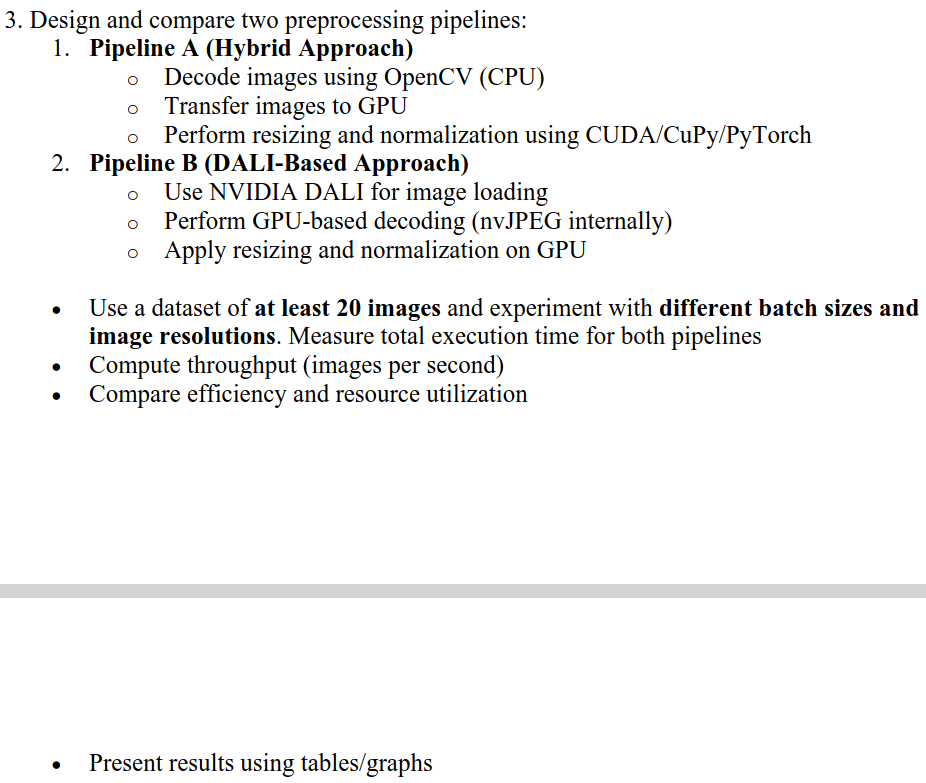

This code evaluates the efficiency and throughput across distinct batch sizes and resolutions for both the Hybrid and DALI-based methodologies.

Task 3 Results:
 Batch Size  Resolution  Hybrid Time (s)  DALI Time (s)  Hybrid (img/s)  DALI (img/s)
          4         256           0.0912         0.0304          219.32        657.55
          4         512           0.0628         0.0311          318.55        643.64
         10         256           0.0523         0.0162          382.50       1237.39
         10         512           0.0483         0.0193          414.40       1037.39


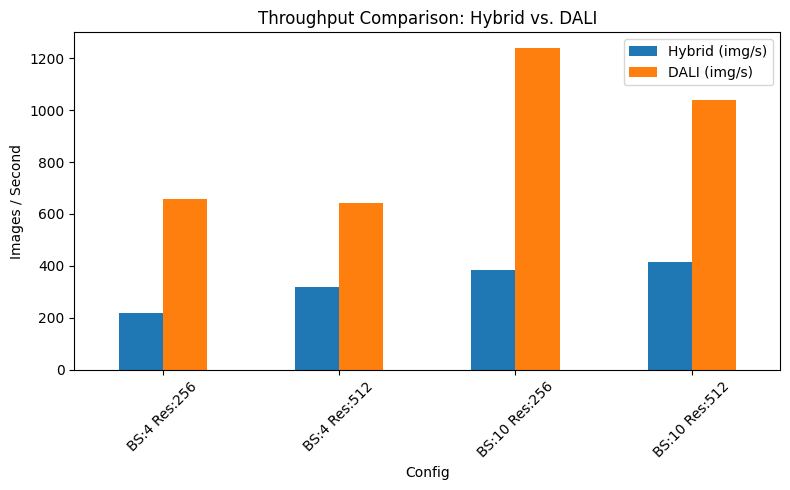

In [12]:
def hybrid_pipeline(paths, batch_size, size):
    start = time.time()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_tensors = []
        for p in batch_paths:
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            batch_tensors.append(img)
        batch = torch.tensor(np.array(batch_tensors)).cuda().permute(0, 3, 1, 2)
        batch = F.resize(batch, [size, size], antialias=True)
        batch = batch.float() / 255.0
    torch.cuda.synchronize()
    return time.time() - start

class DALIPipeline(Pipeline):
    def __init__(self, batch_size, num_threads, device_id, files, size):
        super().__init__(batch_size, num_threads, device_id, seed=12)
        self.input = fn.readers.file(files=files)
        self.decode = fn.decoders.image(self.input[0], device="mixed", output_type=types.RGB)
        self.resize = fn.resize(self.decode, resize_x=size, resize_y=size)
        self.norm = fn.crop_mirror_normalize(self.resize, dtype=types.FLOAT, mean=[0., 0., 0.], std=[255., 255., 255.])

    def define_graph(self):
        return self.norm

def dali_pipeline_run(paths, batch_size, size):
    pipe = DALIPipeline(batch_size=batch_size, num_threads=2, device_id=0, files=paths, size=size)
    pipe.build()
    start = time.time()
    iters = (len(paths) + batch_size - 1) // batch_size
    for _ in range(iters):
        pipe.run()
    return time.time() - start

subset3 = image_paths[:20]
results = []

for bs in [4, 10]:
    for size in [256, 512]:
        t_hybrid = hybrid_pipeline(subset3, bs, size)
        t_dali = dali_pipeline_run(subset3, bs, size)

        results.append({
            "Batch Size": bs,
            "Resolution": size,
            "Hybrid Time (s)": round(t_hybrid, 4),
            "DALI Time (s)": round(t_dali, 4),
            "Hybrid (img/s)": round(20 / t_hybrid, 2),
            "DALI (img/s)": round(20 / t_dali, 2)
        })

df3 = pd.DataFrame(results)
print("Task 3 Results:")
print(df3.to_string(index=False))

df3["Config"] = "BS:" + df3["Batch Size"].astype(str) + " Res:" + df3["Resolution"].astype(str)
df3.plot(x="Config", y=["Hybrid (img/s)", "DALI (img/s)"], kind="bar", figsize=(8, 5))
plt.title("Throughput Comparison: Hybrid vs. DALI")
plt.ylabel("Images / Second")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?**

The Hybrid method suffers from PCIe bottlenecks since the CPU must first fully decode the compressed image, then send the large, uncompressed tensor data to the GPU. DALI avoids this by sending the compressed JPEG bitstream directly to the GPU, where it is fully decoded in VRAM using nvJPEG. All subsequent resizing and normalization are also performed on the GPU, significantly reducing host-to-device memory traffic and preventing CPU thread starvation.